### Importing Required Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Reading and Understanding 

In [53]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [54]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


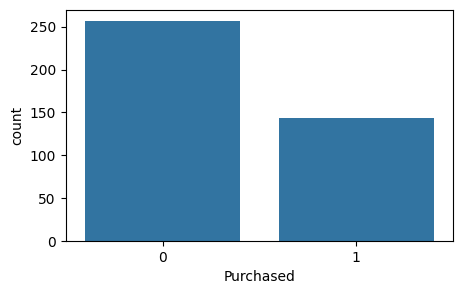

Purchased
0    257
1    143
Name: count, dtype: int64

In [55]:
plt.figure(figsize=[5,3])
sns.countplot(data = df , x = df['Purchased'])
plt.show()
df['Purchased'].value_counts()

In [56]:
# missing values
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [57]:
# drop the UserId column
df.drop(columns = 'User ID',inplace=True)

In [58]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   EstimatedSalary  400 non-null    int64 
 3   Purchased        400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


<Figure size 400x200 with 0 Axes>

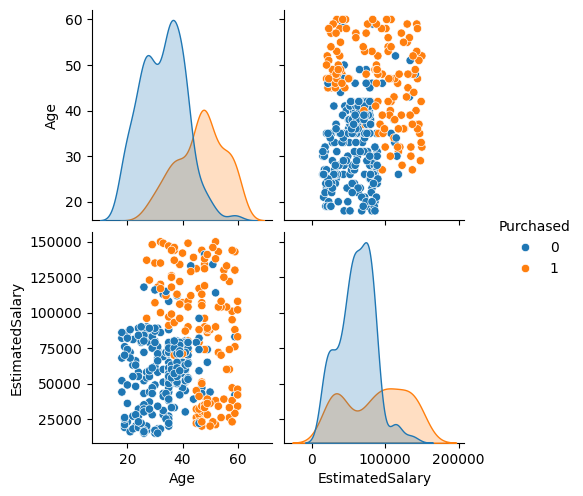

In [59]:
# correlation of data
plt.figure(figsize=[4,2])
sns.pairplot(df,hue = 'Purchased')
plt.show()

### splitting Data into X and Y

In [60]:
x = df[['Age','EstimatedSalary']]
y = df['Purchased']

### Splitting data into training and testing data

In [61]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25,random_state=1)

#### Model

In [62]:
# importing Model class using sklearn 
from sklearn.neighbors import KNeighborsClassifier

# creating instance of class
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model
knn.fit(xtrain,ytrain)

# precit the model
ypred = knn.predict(xtest)

In [63]:
# predcited_df = xtest

In [64]:
# predcited_df['ytest Actual'] = ytest
# predcited_df['ypred Predicted'] = ypred

In [65]:
# predcited_df

In [66]:
# Evaluation matrix
from sklearn.metrics import accuracy_score,classification_report

In [67]:
# accuracy_score
accuracy_score(ytest,ypred)

0.76

In [68]:
# classification_report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        58
           1       0.74      0.67      0.70        42

    accuracy                           0.76       100
   macro avg       0.76      0.75      0.75       100
weighted avg       0.76      0.76      0.76       100



In [69]:
# hyperparameter tunning for k

accuracy = []

for k in range(1,31):
    # creating instance of class
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Fit the model
    knn.fit(xtrain,ytrain)
    
    # precit the model
    ypred = knn.predict(xtest)

    acc = accuracy_score(ytest,ypred)
    accuracy.append(acc)

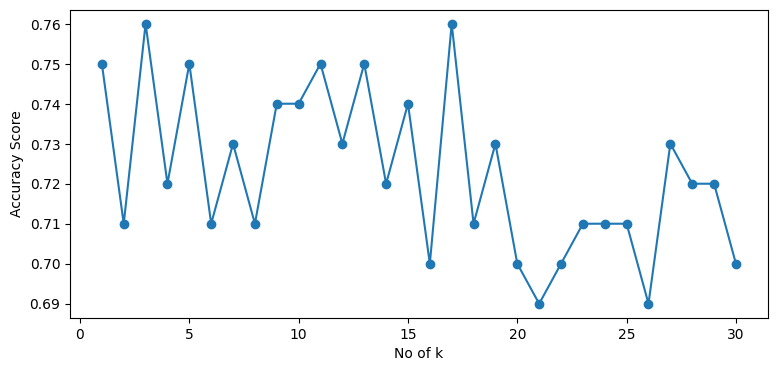

In [76]:
plt.figure(figsize=[9,4])
plt.plot(range(1,31),accuracy,marker = 'o')
plt.xlabel('No of k')
plt.ylabel('Accuracy Score')
plt.show()

### final Model

In [77]:
# importing Model class using sklearn 
from sklearn.neighbors import KNeighborsClassifier

# creating instance of class
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model
knn.fit(xtrain,ytrain)

# precit the model
ypred = knn.predict(xtest)

In [78]:
predcited_df = xtest
predcited_df['ytest Actual'] = ytest
predcited_df['ypred Predicted'] = ypred

In [79]:
predcited_df

,Age,EstimatedSalary,ytest Actual,ypred Predicted
398,36,33000,0,0
125,39,61000,0,0
328,36,118000,1,1
339,39,122000,1,1
172,26,118000,0,1
...,...,...,...,...
300,58,38000,1,1
277,49,88000,1,1
289,37,78000,1,0
260,35,77000,0,0
